In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
torch.manual_seed(42) if not torch.cuda.is_available() else torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# Implicit Neural Networks

For $x$, the input, and $z$, the output, find a $z$ that fulfills:
$$
g(x, z) = 0,
$$
where 
$$
g(x, z) = z - activation(Wz + x)
$$, 
which is just a reformulation showing that $z^*$ is the the fixed point solution:
$z^* = activation(Wz^* + x)$

In [3]:
class FixedPointIterationLayer(nn.Module):
    def __init__(self, in_out_dim, tol=1e-4, activation="relu", max_iter=50):
        super().__init__()
        self.linear = nn.Linear(in_out_dim, in_out_dim, bias=False)

        if activation == 'tanh':
            self.activation = torch.tanh
        else:
            self.activation = nn.functional.relu

        self.max_iter = max_iter
        self.tol = tol

    def forward(self, x):
        # Initialize z at zero
        z = torch.zeros_like(x)

        self.iterations = 0

        while self.iterations < self.max_iter:
            z_out = self.linear(z) + x
            z_out = self.activation(z_out)

            # Check convergence
            self.loss = torch.linalg.norm(z - z_out, ord=2)
            z = z_out
            self.iterations += 1

            if self.loss < self.tol:
                break

        return z

In [4]:
layer = FixedPointIterationLayer(25)
X = torch.randn(10, 25)
Z = layer(X)
print(f"Found fixed point solution after {layer.iterations} iterations with an error of {layer.loss}")

Found fixed point solution after 18 iterations with an error of 8.31157376524061e-05


### Train on MNIST

In [4]:
mnist_train = datasets.MNIST(".", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(".", train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=100, shuffle=False)

Label: 7


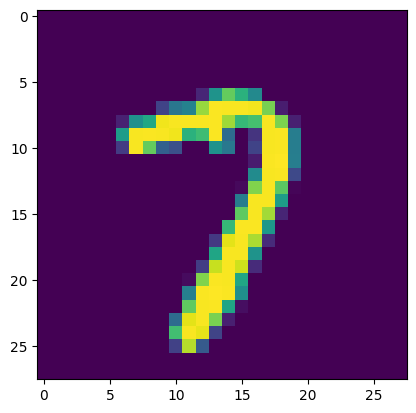

In [5]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))
i = 0
print("Label:", labels[i].item())
plt.imshow(images[i].view(28,28))
plt.show()

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# flattened mnist image tensor have dimensions (n x 784)
image_dim = 28 * 28
model_fixedPointIt = nn.Sequential(
    nn.Flatten(),
    nn.Linear(image_dim, 100),                      # input layer
    FixedPointIterationLayer(100, max_iter=500),   # rolled out fixed point layer
    nn.Linear(100, 10)                              # output layer
).to(device)

In [8]:
opt = optim.SGD(model_fixedPointIt.parameters(), lr=0.1)

In [ ]:
from tqdm import tqdm

def train(loader, model, opt, train=True):
    total_loss = 0
    total_error = 0
    
    criterion = nn.CrossEntropyLoss()

    model.train() if train else model.eval()

    for X, y in tqdm(loader, desc="Train" if train else "Test"):
        X = X.to(device)
        y = y.to(device)

        y_pred = model(X)
        loss = criterion(y_pred, y)

        if train:
            opt.zero_grad()
            loss.backward()

            if sum(torch.sum(torch.isnan(para.grad)) for para in model.parameters()) == 0:
                opt.step()

        total_error += (y_pred.max(dim=1)[1] != y).sum().item()

        # mean loss per sample in batch
        # Multiplying by batch size of current batch to account for different batch sizes, 
        # and make sure the contribution of this batches' loss to the total is made proportional to the batch size
        total_loss += loss.item() * X.shape[0]

    return total_loss / len(loader.dataset), total_error / len(loader.dataset)

In [11]:
for i in range(8):
    if i == 5:
        opt.param_groups[0]["lr"] = 1e-2    
    
    train_loss, train_error = train(train_loader, model_fixedPointIt, opt) 

    print("Train Error:", train_error)
    print("Train Loss:", train_loss)

Train: 100%|██████████| 600/600 [01:02<00:00,  9.56it/s]


Train Error: 0.12761666666666666
Train Loss: 0.42841041505336763


Train: 100%|██████████| 600/600 [01:15<00:00,  7.98it/s]


Train Error: 0.05305
Train Loss: 0.17501528155679505


Train: 100%|██████████| 600/600 [01:22<00:00,  7.25it/s]


...

Train Error: 0.016433333333333335
Train Loss: 0.055405187273863704


Train: 100%|██████████| 600/600 [02:15<00:00,  4.42it/s]


Train Error: 0.01485
Train Loss: 0.05003571839459861


Train: 100%|██████████| 600/600 [02:27<00:00,  4.06it/s]

Train Error: 0.014233333333333334
Train Loss: 0.04745474875671789


In [12]:
test_loss, test_error = train(test_loader, model_fixedPointIt, opt, train=False) 
print("Test Error:", test_error)
print("Test Loss:", test_loss)

Test: 100%|██████████| 100/100 [00:22<00:00,  4.42it/s]

Test Error: 0.025
Test Loss: 0.08455677756137447


In [25]:
images_test, labels_test = next(iter(test_loader))
i = 65
output_test = model_fixedPointIt(images_test[i])
print("model classification output: ", output_test)
print(f"True Label {labels_test[i]}, model output {output_test.max(dim=1)[1].item()}")

model classification output:  tensor([[-3.2266, -0.7329, -0.5040,  0.0323,  6.4092,  1.1240, -2.3861,  0.1361,
         -0.5268,  1.4917]], grad_fn=<AddmmBackward0>)
True Label 4, model output 4
